# 1. Getting started, and what the outputs are

This notebook checks that Arterial is installed and can find its model weights, runs the pipeline driver with every stage switched off, and then walks through a finished case directory: what each file is, which stage writes it and which stage reads it.

It runs in under a minute and needs no GPU. Later notebooks each take one stage in depth.

In [1]:
import os
from arterial_nb import *
from arterial import model_registry

print("package directory :", os.environ["arterial_dir"])
print("models directory  :", model_registry.models_dir())

package directory : /home/perecanals/arterial_open_source_test/arterial/arterial
models directory  : /home/perecanals/arterial_open_source_test/arterial/arterial/models



Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



## Where the weights are

The weights are not part of the repository; `scripts/download_models.sh` fetches them from Zenodo. The package resolves their location in this order: the `ARTERIAL_MODELS_DIR` variable if set, otherwise `models/` inside the package directory.

In [2]:
rows = []
for parts in [("segmentation", "extracranial_vessels"), ("segmentation", "intracranial_vessels"), ("segmentation", "totalsegmentator_mandible"),
              ("landmark_detection",), ("vessel_labelling", "extracranial_vessels"), ("access_prediction",)]:
    path = model_registry.model_path(*parts)
    n_files = sum(len(f) for _, _, f in os.walk(path)) if os.path.isdir(path) else 0
    size_mb = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(path) for f in fs) / 1e6 if n_files else 0
    rows.append(["/".join(parts), "yes" if n_files else "MISSING", n_files, round(size_mb)])
table(rows, columns=["model", "installed", "files", "MB"])

,model,installed,files,MB
0,segmentation/extracranial_vessels,yes,4,490
1,segmentation/intracranial_vessels,yes,4,494
2,segmentation/totalsegmentator_mandible,yes,5,247
3,landmark_detection,yes,2,39
4,vessel_labelling/extracranial_vessels,yes,7,1
5,access_prediction,yes,6,0


## The pipeline driver

`ArterialProcessor` wraps the six stages. Each `skip_*` flag switches one off. With everything skipped it just reports the stage timings, which is a cheap way to confirm the wiring before a real run.

In [3]:
from argparse import Namespace
from arterial.run.processor import ArterialProcessor

args = Namespace(case_dir=case("getting_started"), cta_nifti_path=fixture("cta.nii.gz"),
                 skip_segmentation=True, skip_centerline_extraction=True, skip_landmark_detection=True,
                 skip_vessel_labelling=True, skip_feature_extraction=True, skip_access_prediction=True)
with quiet():
    times = ArterialProcessor(args).perform_analysis()
table([[k.replace("_time", ""), round(v, 3)] for k, v in times.items()], columns=["stage", "seconds"])

,stage,seconds
0,segmentation,0.0
1,centerline_extraction,0.0
2,landmark_detection,0.0
3,vessel_labelling,0.0
4,feature_extraction,0.0
5,access_prediction,0.0
6,total,0.0


The same flags exist on the command line:

```bash
python perform_analysis.py -cd /path/to/case -cnp /path/to/cta.nii.gz --fast_segmentation
```

## Anatomy of a finished case

Every stage writes into `case_dir/<mode>/`. The table below lists the files of a completed extracranial run, who writes them and who reads them next.

In [4]:
import glob
mode_dir = derived()
rows = []
for path in sorted(glob.glob(os.path.join(mode_dir, "**", "*"), recursive=True)):
    rel = os.path.relpath(path, mode_dir)
    if os.path.isdir(path) or rel.count(os.sep) > 1:
        continue
    rows.append([rel, round(os.path.getsize(path) / 1e6, 2)])
table(rows, columns=["file", "MB"])

,file,MB
0,branch_model.vtk,0.34
1,branch_models/branch_model_0.vtk,0.34
2,branch_models/branch_model_1.vtk,0.06
3,branch_models/branch_model_2.vtk,0.05
4,centerline_segments_array.npy,0.11
5,centerlines/centerlines_0.vtk,0.17
6,centerlines/centerlines_1.vtk,0.03
7,centerlines/centerlines_2.vtk,0.03
8,endpoints/endpoints_0.json,0.01
9,endpoints/endpoints_1.json,0.01


In [5]:
producers = [
    ["segmentation.nii.gz", "segmentation", "centerline extraction, landmark refinement", "binary vessel mask on the CTA grid"],
    ["segmentation.vtk / .stl", "centerline extraction", "vessel geometry export", "vessel surface mesh"],
    ["segmentations/, centerlines/, networks/, endpoints/", "centerline extraction", "same stage", "one file per connected island"],
    ["branch_models/, branch_model.vtk", "centerline extraction", "feature extraction", "centerlines split into branches, with a Blanking flag near bifurcations"],
    ["centerline_segments_array.npy", "centerline extraction", "vessel labelling, feature extraction", "one row per centerline segment: coordinates and radii"],
    ["segments_graph.pickle / _pred.pickle", "vessel labelling", "feature extraction", "one edge per segment; _pred carries the predicted vessel type"],
    ["local_graph.pickle", "feature extraction", "access prediction, geometry export", "dense resampled tree with every feature"],
    ["single_segments/*.pickle", "feature extraction", "geometry export", "one graph per named vessel"],
    ["supersegments/*.pickle", "feature extraction", "access prediction", "eight catheter pathways: access x side x circulation"],
    ["landmarks.json / landmarks_slicer.json", "landmark detection", "individual centerlines, carotid analysis", "six bifurcation points in RAS mm"],
    ["individual_centerlines/", "landmark detection", "per-vessel features", "centerlines between landmark pairs"],
    ["access_prediction/", "access prediction", "reporting", "probability, uncertainty and attention map per pathway"],
]
table(producers, columns=["file(s)", "written by", "read by", "what it holds"])

,file(s),written by,read by,what it holds
0,segmentation.nii.gz,segmentation,"centerline extraction, landmark refinement",binary vessel mask on the CTA grid
1,segmentation.vtk / .stl,centerline extraction,vessel geometry export,vessel surface mesh
2,"segmentations/, centerlines/, networks/, endpo...",centerline extraction,same stage,one file per connected island
3,"branch_models/, branch_model.vtk",centerline extraction,feature extraction,"centerlines split into branches, with a Blanki..."
4,centerline_segments_array.npy,centerline extraction,"vessel labelling, feature extraction",one row per centerline segment: coordinates an...
5,segments_graph.pickle / _pred.pickle,vessel labelling,feature extraction,one edge per segment; _pred carries the predic...
6,local_graph.pickle,feature extraction,"access prediction, geometry export",dense resampled tree with every feature
7,single_segments/*.pickle,feature extraction,geometry export,one graph per named vessel
8,supersegments/*.pickle,feature extraction,access prediction,eight catheter pathways: access x side x circu...
9,landmarks.json / landmarks_slicer.json,landmark detection,"individual centerlines, carotid analysis",six bifurcation points in RAS mm


## Two things every stage shares

Positions are in RAS millimetres from the image affine, so files from different stages line up in 3D Slicer without conversion. Radii come from the maximum inscribed sphere computed by VMTK and are carried along from the centerlines into every graph.

CTA shape (512, 512, 782), spacing [0.54 0.54 0.4 ] mm, orientation ('L', 'P', 'S')
28 centerline segments, 3400 points; local graph with 620 nodes


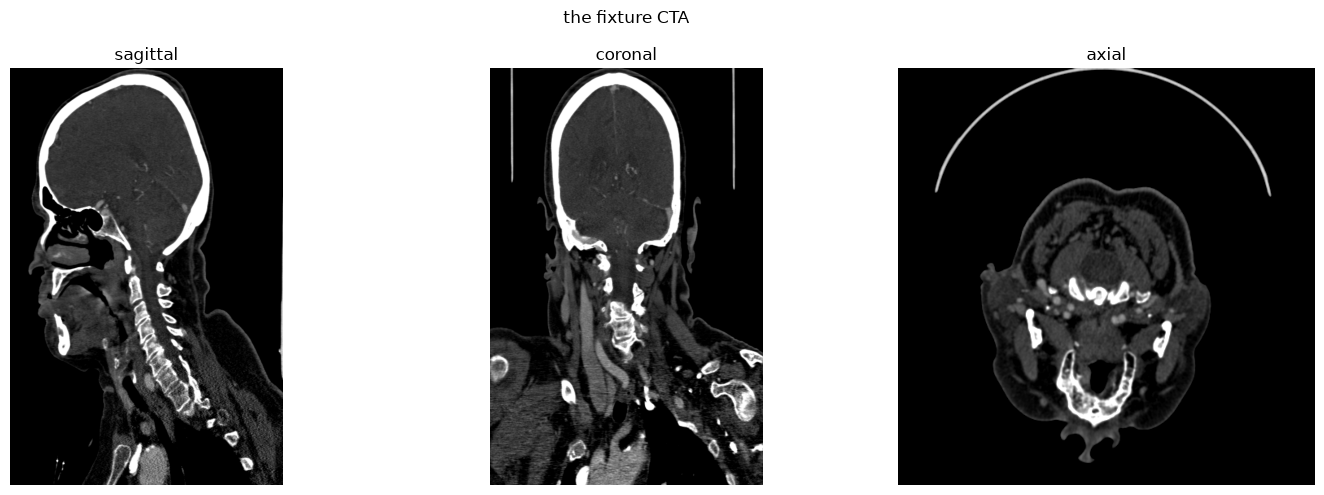

In [6]:
import numpy as np, nibabel as nib
from arterial.io.load_and_save_operations import load_pickle, load_numpy

cta = nib.load(fixture("cta.nii.gz"))
segments = load_numpy(derived("centerline_segments_array.npy"))
graph = load_pickle(derived("local_graph.pickle"))
print(f"CTA shape {cta.shape}, spacing {np.round(np.abs(np.diag(cta.affine)[:3]), 2)} mm, orientation {nib.aff2axcodes(cta.affine)}")
print(f"{len(segments)} centerline segments, {sum(len(s) for s in segments[:, 0])} points; local graph with {graph.number_of_nodes()} nodes")
show_slices(np.asarray(cta.dataobj), window=(-100, 600), title="the fixture CTA");